# 1. Introduction
    This analysis explores the Pakistan House Prices and Property Listings dataset to understand the patterns and factors affecting property prices in different cities and locations. Real estate prices are influenced by multiple factors such as location, number of bedrooms, area size, property type, and amenities. Through this Exploratory Data Analysis (EDA), we aim to visualize price distributions, city-wise property trends, and property type proportions using charts and donut charts. Furthermore, this project applies machine learning models to predict house prices based on property features, allowing us to identify the most accurate model for real estate price prediction.

# 2. Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 3. Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sarcasmos/pakistan-house-prices-and-property-listings/Pakistan House Prices and Property Listings.csv")
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,2/4/2019,NaN,NaN
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,5/4/2019,NaN,NaN
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,7/17/2019,NaN,NaN
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,4/5/2019,NaN,NaN
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director


In [3]:
df.tail()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
168441,17355248,6754,https://www.zameen.com/Property/gulshan_e_maym...,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,9.6 Marla,For Sale,6,7/18/2019,Al Shahab Enterprises,Shahmir
168442,17355249,680,https://www.zameen.com/Property/gadap_town_gul...,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,8 Marla,For Sale,3,7/18/2019,Al Shahab Enterprises,Shahmir
168443,17355250,6757,https://www.zameen.com/Property/gulshan_e_maym...,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,9.6 Marla,For Sale,6,7/18/2019,Al Shahab Enterprises,Shahmir
168444,17355251,6752,https://www.zameen.com/Property/gulshan_e_maym...,House,11000000,Gadap Town,Karachi,Sindh,25.013265,67.120818,0,7.8 Marla,For Sale,3,7/18/2019,Al Shahab Enterprises,Shahmir
168445,17355287,10045,https://www.zameen.com/Property/bahria_town_ka...,House,9000000,Bahria Town Karachi,Karachi,Sindh,25.113565,67.353811,3,9.4 Marla,For Sale,3,7/18/2019,ZPN Real Estate & Builders,Ali Raza


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
dtypes: float64(2), int64(5), obje

In [5]:
df.describe()

,property_id,location_id,price,latitude,longitude,baths,bedrooms
count,1.684460e+05,168446.000000,1.684460e+05,168446.000000,168446.000000,168446.000000,168446.000000
mean,1.559626e+07,4375.936395,1.776576e+07,29.859519,71.239804,2.874227,3.179422
std,2.251207e+06,3776.561581,3.531003e+07,3.807870,3.133042,2.463400,1.971401
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000
25%,1.488320e+07,1058.000000,1.750000e+05,24.948536,67.130363,0.000000,2.000000
50%,1.665851e+07,3286.000000,8.500000e+06,31.459784,73.056182,3.000000,3.000000
75%,1.708662e+07,7220.000000,1.950000e+07,33.560887,73.259870,4.000000,4.000000
max,1.735772e+07,14220.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000


In [6]:
df.columns

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent'],
      dtype='object')

# 4. Data Cleaning

In [7]:
# Remove unnecessary columns
df.drop(['property_id', 'location_id', 'page_url', 'latitude', 'longitude', 'agency', 'agent'], axis=1, inplace=True)

# Handle missing values
df.dropna(inplace=True)

# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'])
df['year'] = df['date_added'].dt.year

# Remove date column
df.drop('date_added', axis=1, inplace=True)

print(df.isnull().sum())

property_type    0
price            0
location         0
city             0
province_name    0
baths            0
area             0
purpose          0
bedrooms         0
year             0
dtype: int64


# 5. EDA (Charts)

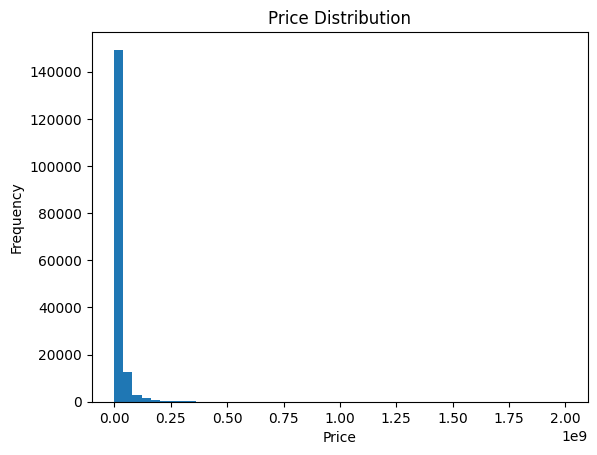

In [8]:
plt.figure()
plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# City Count Chart

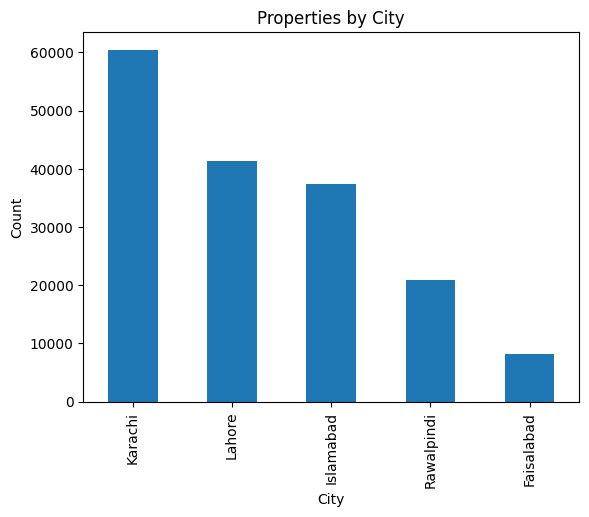

In [9]:
df['city'].value_counts().plot(kind='bar')
plt.title("Properties by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

# Bedrooms vs Price

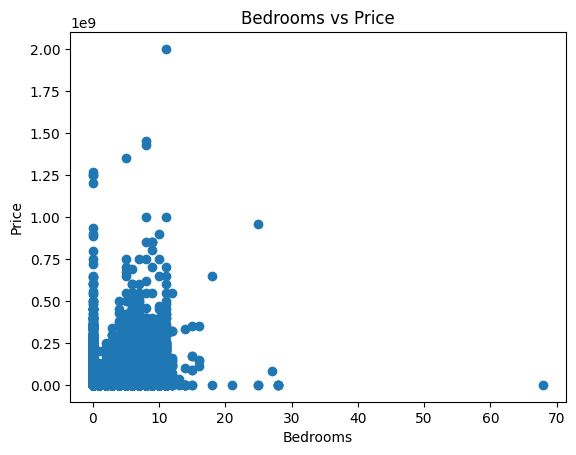

In [10]:
plt.figure()
plt.scatter(df['bedrooms'], df['price'])
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

# 6. Encoding (Convert Text to Numbers)

In [11]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 7. Define X and y

In [12]:
X = df.drop('price', axis=1)
y = df['price']

# 8. Train Test Split


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Train Multiple Models

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [15]:
lr_pred = lr.predict(X_test)
lr_pred

array([49351866.71594715, -8488284.76844978, 35290015.99462032, ...,
       32001209.03689384, 14907022.53252697, 21739965.68916225])

# Random Forest (Best Model Usually) 

In [16]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [17]:
rf_pred = rf.predict(X_test)
rf_pred

array([1.10718229e+08, 4.16515000e+04, 2.38528911e+07, ...,
       1.32882396e+08, 1.18176656e+05, 3.20113338e+05])

# 10. Model Evaluation

In [18]:
def evaluate(y_test, pred, model_name):
    print(model_name)
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2 Score:", r2_score(y_test, pred))

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

Linear Regression
MAE: 14564145.684943937
RMSE: 30276187.34785882
R2 Score: 0.20918610422547745
Random Forest
MAE: 3828994.828057899
RMSE: 15087371.466697706
R2 Score: 0.8036191703452309


# 11.Prediction

In [19]:
# Example prediction
sample = X.iloc[0:1]
prediction = rf.predict(sample)

print("Predicted Price:", prediction)

Predicted Price: [6776061.65936999]


# Final Conclusion:
    Two machine learning models were trained: Linear Regression and Random Forest. The models were evaluated using MAE, RMSE, and R2 Score. Random Forest performed significantly better than Linear Regression with an R2 Score of 0.80, indicating strong predictive performance. Therefore, Random Forest was selected as the final model for house price prediction.

# DEPLOYMENT METHOD 

In [20]:
def predict_price(city, location, province_name, purpose, bedrooms, baths, area, property_type, year):
    
    input_data = pd.DataFrame({
        'city':[city],
        'location':[location],
        'province_name':[province_name],
        'purpose':[purpose],
        'bedrooms':[bedrooms],
        'baths':[baths],
        'area':[area],
        'property_type':[property_type],
        'year':[year]
    })
    
    # Encoding
    for col in input_data.select_dtypes(include='object').columns:
        input_data[col] = le.fit_transform(input_data[col])
    
    input_data = input_data[X.columns]
    
    prediction = rf.predict(input_data)[0]
    
    # Convert to plain Python float for clean output
    prediction = float(prediction)
    
    print("Predicted House Price:", round(prediction, 2))
    return prediction

# Test

In [21]:
price = predict_price("Karachi","DHA Defence","Sindh","For Sale",3,3,120,"House",2023)

Predicted House Price: 421110.0
